In [1]:
from data.cleaning import read_csv
from core import Config
import pandas as pd

config = Config()
all_df: pd.DataFrame = read_csv(
    #filepath=config.eda_filtered_dir / "eda_filtered_historic_2026.csv",
    filepath=config.data_dir / "datasets" / "median" / "median_imputed.csv",
    #dtypes_filepath=config.eda_filtered_dir / "eda_filtered_historic_dtypes_2026.csv",
    dtypes_filepath=config.data_dir / "datasets" / "median" / "median_imputed_dtypes.csv",
    index_list=[0]
)

Start global: univariate checks
On the full dataset (no grouping yet):

Plot and summarize each key numeric feature: histograms, boxplots, min/median/max, IQR.

Compute simple outlier heuristics per feature:

- IQR fences
- Z‑scores

This gives you a first feel for which features are “messy” and where to focus.

Minimum value: 0.0
Maximum value: 53.0533711177524
Median value: 52.3808545518619
IQR value: TR.AnalyticAccountingControvScore   0.76738
dtype: Float64 Z-score:                  Z-score
Instrument Date         
SCATC.OL   2018  0.16718
           2019  0.23362
           2020  0.15402
           2021  0.05931
           2022 -0.04488
...                  ...
8219.T     2020  0.15402
           2021  0.05931
           2022 -0.04488
           2023  0.05659
           2024  0.12846

[21156 rows x 1 columns]


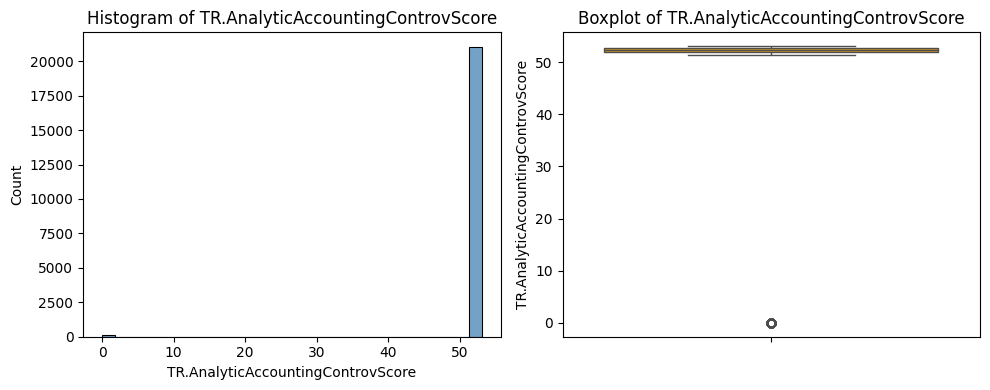

In [20]:
num_cols: list[str] = all_df.select_dtypes('number').columns.to_list()
remove_columns: set[str] = {
    'Date',
    'TR.AnalyticAntiTakeoverDevices',
    'TR.AnalyticAntiCompetitionControvScore',
    'TR.AnalyticAuditCommExpertiseScore',
    'TR.AnalyticAuditCommMgtIndScore,',
    'TR.AnalyticBoardAttendanceScore',
    'TR.AnalyticBoardFunctionsPolicyScore',
    'TR.AnalyticBoardReelectionScore',
    'TR.AnalyticBoardSizeMore10Less8',
    'TR.AnalyticBoardSizeMore10Less8Score',
    'TR.AnalyticBoardStructurePolicyScore',
    'TR.BoardExternalConsultantsScore',
    'TR.BoardSuccessionPlanScore',
    'TR.AnalyticExperiencedBoard',
    'TR.AnalyticCustomerControvScore',
    'TR.AnalyticBoardFemale',
    'TR.AnalyticBoardSpecificSkills',
    'TR.AnalyticIndepBoard',
    'TR.AnalyticNonExecBoard',
    'TR.AnalyticBoardAffiliations',
    'TR.AnalyticAuditCommMgtIndScore',
    'TR.AnalyticCEOChairmanSeparationScore',
}
num_cols = list(set(num_cols) - remove_columns)
num_cols.sort()
feature = num_cols[0]

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats.mstats as mstats

def hist_and_box_sns(df, column, bins=40):
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

    sns.histplot(data=df, x=column, bins=bins, ax=ax_hist, kde=False, color="steelblue")
    ax_hist.set_title(f"Histogram of {column}")

    sns.boxplot(y=df[column], ax=ax_box, orient="v", color="orange")
    ax_box.set_title(f"Boxplot of {column}")

    fig.tight_layout()
    return fig, (ax_hist, ax_box)

dataframe = all_df[['Instrument', 'Date', feature]].dropna().set_index(['Instrument', 'Date'])
fig, axes = hist_and_box_sns(dataframe, feature, bins=30)
minimum_value = dataframe[[feature]].min().values[0]
maximum_value = dataframe[[feature]].max().values[0]
median_value = dataframe[[feature]].median().values[0]
iqr_value = dataframe[[feature]].quantile(0.75) - dataframe[[feature]].quantile(0.25)
z_values = mstats.zscore(dataframe[[feature]], axis=0)
z_score = pd.DataFrame(z_values, index=dataframe.index, columns=['Z-score'])
print(f"Minimum value: {minimum_value}\nMaximum value: {maximum_value}\nMedian value: {median_value}\nIQR value: {iqr_value} Z-score: {z_score}")
feature_df = dataframe.join(z_score).reset_index()

thr = 3
mask_outlier = feature_df['Z-score'].abs() > thr

# companies with at least one outlier for that feature
companies_with_outlier = feature_df.loc[mask_outlier, 'Instrument'].unique()

# subset: all years for those companies
df_focus = feature_df[feature_df['Instrument'].isin(companies_with_outlier)]
df_focus.sort_values(['Instrument', 'Date'], inplace=True)

In [ ]:
for col in num_cols:
    print(col)

In [4]:
boolean_columns = all_df.select_dtypes('bool').columns.to_list()
boolean_columns.sort()
for col in boolean_columns:
    print(col)

TR.AdultEntertainmentProducer
TR.AdultEntertainmentRetailer
TR.Agrochemical5PctRevenue
TR.Alcohol
TR.AlcoholProducer
TR.AlcoholRetailing
TR.AnalyticAccountingControv
TR.AnalyticAuditCommExpertise
TR.AnalyticAuditCommMgtInd
TR.AnalyticBoardAttendance
TR.AnalyticBoardBackground
TR.AnalyticBoardFunctionsPolicy
TR.AnalyticBoardReelection
TR.AnalyticBoardStructurePolicy
TR.AnalyticBriberyFraudControv
TR.AnalyticCEOChairmanSeparation
TR.AnalyticCSRCompIncentives
TR.AnalyticChairpersonIndependent
TR.AnalyticChiefLegalOfficerReporttoBoard
TR.AnalyticCompCommMgtInd
TR.AnalyticComplianceHeadReporttoBoard
TR.AnalyticConsumerComplaints
TR.AnalyticCurrentCEOChairmanDuality
TR.AnalyticCustomerControv
TR.AnalyticEnvControv
TR.AnalyticEqualShareholderRights
TR.AnalyticExecCompControv
TR.AnalyticExecCompLTObjectives
TR.AnalyticExecCompPolicy
TR.AnalyticExecIndividualComp
TR.AnalyticGHGEmissionsIntensityScope1and2ParisAligned
TR.AnalyticGHGEmissionsScope1and2ParisAligned
TR.AnalyticHumanRightsPolicy
TR.